In [ ]:
%matplotlib widget
import torch
import matplotlib.pyplot as plt
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm
from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.operations import sph_op
from diffSPH.kernels import getSPHKernelv2

from diffSPH.dataLoader import *
from BasisConvolution.convLayerv3 import BasisConvLayer



In [4]:
# folder = '/mnt/data/homeBak/dev/SFBC/datasets/test_case_II/train/'
# folder = '/mnt/data/homeBak/dev/SFBC/datasets/test_case_III/train/'
# folder = '/mnt/data/dsets/datasetB/export/'
# folder = '/mnt/data/wcsph_datasets/wcsph_flows_free_slip/testing/noObstacle/'
# folder = '/home/winchenbach/dev/datasets/wcsph_flows_no_slip/testing/noObstacle/'
# folder = '/home/winchenbach/dev/datasets/testcase_II/'
# folder = './data'
# folder = '/home/winchenbach/dev/datasets/diffSPH_WCSPH/'
# folder = '../lagrangebench/datasets/2D_LDC_2708_10kevery100_converted/train/'
# folder = '../lagrangebench/datasets/2D_TGV_2500_10kevery100_converted/train/'
# folder = '../diffSPH_public/examples/compressible/data/'
# folder = '/home/winchenbach/dev/datasets/compressibleDataset/16K/data/'
folder = '/home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible/freeSlip/data'

# folder = '/home/winchenbach/dev/SFBC/datasets/test_case_II/train/'

In [5]:
configuration = DataConfiguration(
    frameDistance=1,
    frameSpacing=1,
    maxRollout=1,
    historyLength=1,
    skipInitialFrames=0,
    cutoff=0
)

processed = processFolder(folder, configuration)

for file in processed:
    print(f'File: {file["fileName"]}, FrameCount: {len(file["frames"])}, Samples: {len(file["samples"])}, Style: {file["style"]}, Number of samples: {len(processed[0]["samples"])}, first sample: {processed[0]["samples"][0]}, last sample: {processed[0]["samples"][-1]}')


File: /home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible/freeSlip/data/wcsph_False_False_1_1024_2025-08-11_15-31-00_2470137967.h5, FrameCount: 1023, Samples: 1023, Style: diffSPH, Number of samples: 1023, first sample: 000001, last sample: 001023
File: /home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible/freeSlip/data/wcsph_False_False_1_1024_2025-08-11_15-31-31_2377892769.h5, FrameCount: 1023, Samples: 1023, Style: diffSPH, Number of samples: 1023, first sample: 000001, last sample: 001023
File: /home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible/freeSlip/data/wcsph_False_False_1_1024_2025-08-11_15-32-03_1288098329.h5, FrameCount: 1023, Samples: 1023, Style: diffSPH, Number of samples: 1023, first sample: 000001, last sample: 001023
File: /home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible/freeSlip/data/wcsph_False_False_1_1024_2025-08-11_15-32-41_3703308330.h5, FrameCount: 1023, Samples: 1023, Style: diffSPH, Number of samples: 1023, first 

In [6]:
dataset, datasetLoader = getDataLoader(processed, 4, shuffle = True)
datasetIter = iter(datasetLoader)

nextData = next(datasetIter)
print(f'Next data: {nextData}')

# nextData = [0, 16, 64, 98]
# nextData = [9000]

Next data: [361287, 265724, 223771, 203648]


In [5]:
priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
    dataset, nextData, configuration, device = 'cuda', dtype = torch.float32,
    augmentAngle = False,
)

In [6]:
currentState.densities

tensor([2.0005, 1.8218, 1.6828,  ..., 1.0185, 0.8970, 1.0396], device='cuda:0')

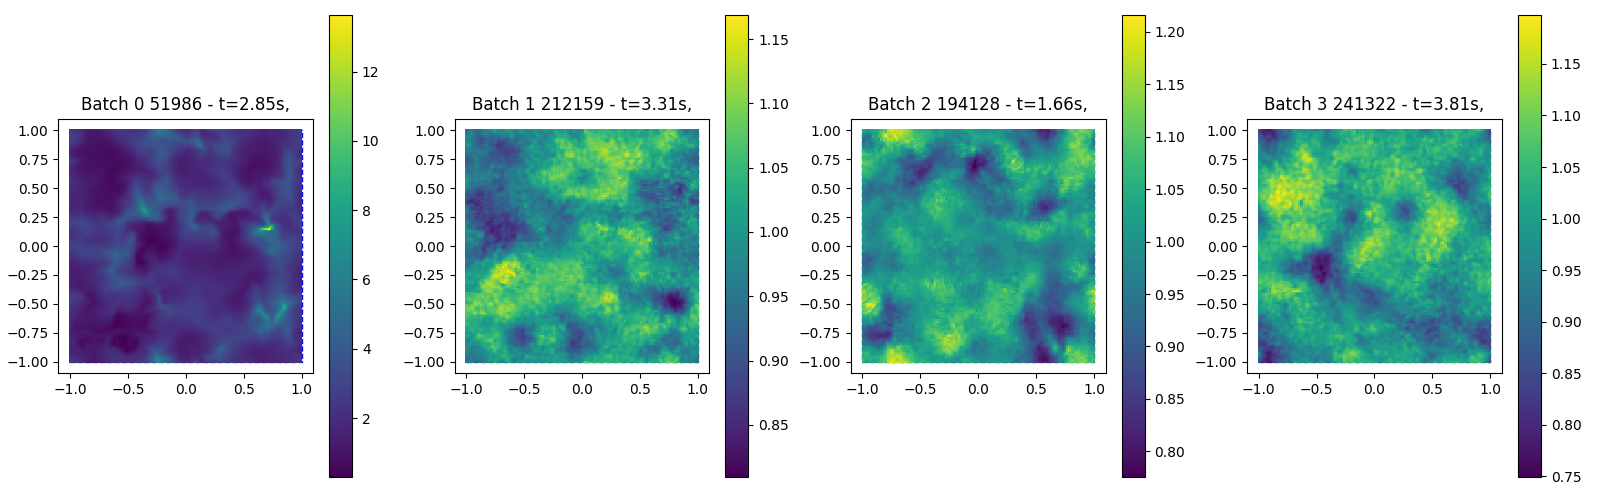

In [7]:
fig, axis = plt.subplots(1, len(nextData), figsize=(len(nextData) * 4, 5), squeeze = False)
# filteredNeighborhood = filterNeighborhoodByKind(currentStates[0], neighborhoods[0], 'noghost')

plots = []
axes = axis.flatten()
for b in range(len(domains)):
    plot = visualizeParticles(fig, axes[b],
                              particles = currentState,
                              domain = domains[b],
                              quantity = currentState.densities,
                              which = 'both',
                              mapping = 'L2',
                              cmap = 'viridis',
                              visualizeBoth=True,
                              kernel = kernelNameToKernel(configs[b]['kernel']),
                              plotDomain = True,
                              gridVisualization=True, markerSize=2,
                              batch = b, streamLines = False)
    axes[b].set_title(f'Batch {b} {nextData[b]} - t={currentState.time[b]:.2f}s,')
    plots.append(plot)

fig.tight_layout()

In [8]:
from neighborhood import evalDistanceTensor

In [9]:

def evalDensity(state, neighborhood, domains, config):
    quantity = torch.ones_like(state.densities)

    return sph_op(
        state, state, domains, getSPHKernelv2('Wendland2'), neighborhood, quantity = state.velocities, supportScheme='gather', operation = 'density'
    )

filteredNeighborhood = filterNeighborhoodByKind(currentState, neighborhoods, 'noghost')
filtered_csr = coo_to_csr(filteredNeighborhood)
print(f'Filtered neighborhood: {filtered_csr}')

rho = evalDensity(currentState, filteredNeighborhood, domains, configs[0])

for b in range(len(domains)):
    updatePlot(plots[b], particles = currentState, quantity = filtered_csr.rowEntries, mapping = 'L2', cmap = 'viridis')
    # updatePlot(plots[b], particles = currentState, quantity = rho, mapping = '.x', cmap = 'RdBu_r')
    
rij, xij, hi, hj = evalDistanceTensor(neighborhoods)

Filtered neighborhood: SparseCSR(indices=tensor([16381, 15872, 15873,  ..., 51054, 54777, 55044], device='cuda:0'), indptr=tensor([      0,      55,     113,  ..., 3596988, 3597043, 3597096],
       device='cuda:0', dtype=torch.int32), rowEntries=tensor([55, 58, 61,  ..., 54, 55, 53], device='cuda:0'), numRows=[16384, 16384, 16384, 16384], numCols=[16384, 16384, 16384, 16384])


In [31]:
testLayer = BasisConvLayer(
    inputFeatures = 1,
    outputFeatures = 1,
    dim = domains[0].dim,

    basisTerms = 4,
    basisFunction = 'linear',
    basisPeriodicity = False,

    biasActive= False,
    cutlassBatchSize= 16,

    mode = 'conv'
).to('cuda', dtype = torch.float32)

optimizer = torch.optim.Adam(testLayer.parameters(), lr=1e-3)

In [35]:
priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
    dataset, nextData, configuration, device = 'cuda', dtype = torch.float32,
    augmentAngle = False,
)

In [36]:
inputFeatures = torch.ones_like(currentState.densities).unsqueeze(-1)

filteredNeighborhood = filterNeighborhoodByKind(currentState, neighborhoods, 'noghost')
edge_index = torch.stack([filteredNeighborhood.row, filteredNeighborhood.col])
# print(edge_index.shape)

rij, xij_, h_i, h_j = evalDistanceTensor(filteredNeighborhood)
edge_attr = xij_ / h_i[:, None] 

out, _ = testLayer(
    x = [inputFeatures, inputFeatures],
    edge_index = edge_index,
    edge_attr = edge_attr,
    batches = 1,
)
rho = evalDensity(currentState, filteredNeighborhood, domains, configs[0]) #/ configs[0]['fluid']['rho0']

print(f'Output shape: {out.shape}'
      f', Input shape: {inputFeatures.shape}, Edge index shape: {edge_index.shape}, Edge attr shape: {edge_attr.shape}')

Output shape: torch.Size([65536, 1]), Input shape: torch.Size([65536, 1]), Edge index shape: torch.Size([2, 3578666]), Edge attr shape: torch.Size([3578666, 2])


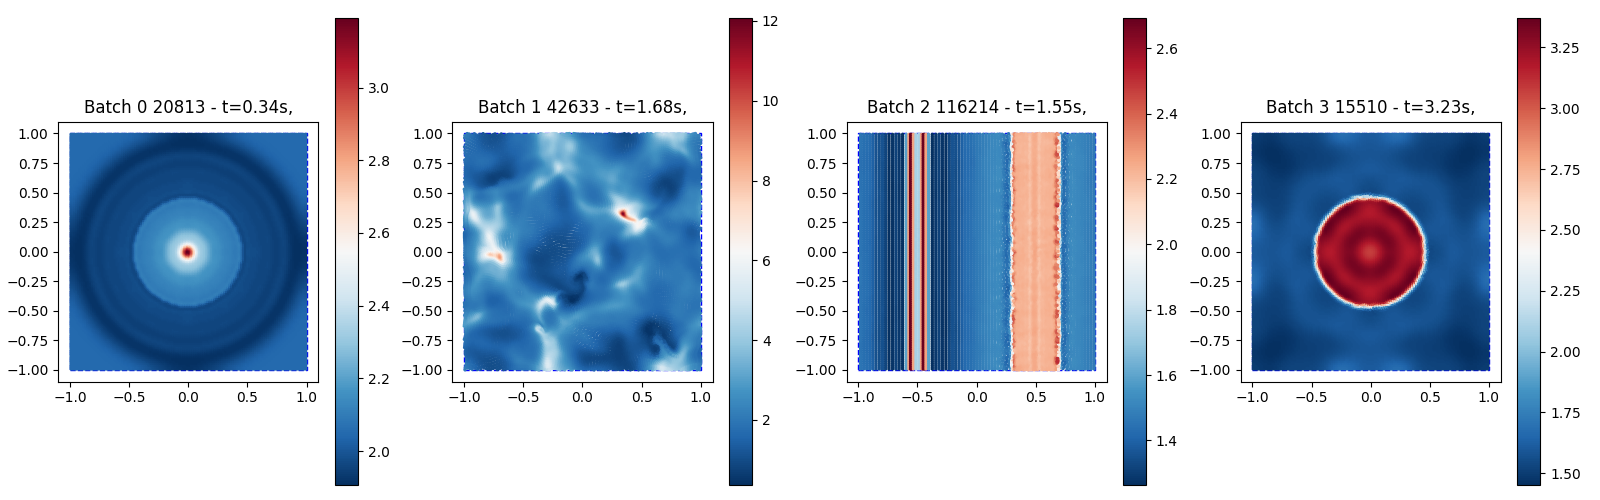

In [37]:
fig, axis = plt.subplots(1, len(nextData), figsize=(len(nextData) * 4, 5), squeeze = False)
# filteredNeighborhood = filterNeighborhoodByKind(currentStates[0], neighborhoods[0], 'noghost')

plots = []
axes = axis.flatten()
for b in range(len(domains)):
    plot = visualizeParticles(fig, axes[b],
                              particles = currentState,
                              domain = domains[b],
                              quantity = rho,
                              which = 'both',
                              mapping = 'L2',
                              cmap = 'RdBu_r',
                              visualizeBoth=True,
                              kernel = kernelNameToKernel(configs[b]['kernel']),
                              plotDomain = True,
                              gridVisualization=False, markerSize=2,
                              batch = b)
    axes[b].set_title(f'Batch {b} {nextData[b]} - t={currentState.time[b]:.2f}s,')
    plots.append(plot)

fig.tight_layout()

In [ ]:
def buildNetwork(
        mode = 'conv',
        basis = 'linear',
        basisTerms = 4,
        layerCount = 2,
        layerWidth = 128,
        inputFeatures = 1,
        outputFeatures = 1,
        dim = 2
):
    testLayerGNN = BasisConvLayer(
    inputFeatures = inputFeatures,
    outputFeatures = outputFeatures,
    dim = dim,

    basisTerms = basisTerms,
    basisFunction = basis,
    basisPeriodicity = False,

    biasActive= False,
    cutlassBatchSize= 16,

    mode = mode, edgeSkip = 'none', mlpProperties = {
            'activation': 'celu',
            'gain': 1,
            'norm': False,
            'preNorm': False,
            'postNorm': False,
            'noLinear': False,
            'bias': False,
            'groups': [1],
            'layout': [layerWidth] * layerCount,
    }).to('cuda', dtype = torch.float32)

    return testLayerGNN

In [39]:
testLayer = buildNetwork(mode = 'conv', basis = 'linear', basisTerms = 4, layerCount = 2, layerWidth = 128)
numParameters = sum(p.numel() for p in testLayer.parameters() if p.requires_grad)
print(f'Number of parameters in the layer: {numParameters}')

Number of parameters in the layer: 16


In [40]:
def trainLayer(testLayer, datasetLoader, iterations, initialLR):

    optimizer = torch.optim.Adam(testLayer.parameters(), lr=initialLR)

    losses = []
    datasetIter = iter(datasetLoader)
    
    for i in (tq := tqdm(range(iterations), leave = False)):
        try:
            batch = next(datasetIter)
        except StopIteration:
            datasetIter = iter(datasetLoader)
            batch = next(datasetIter)
        # nextData = [1024]
        # nextData = [batch[0], batch[0] + 1]  # Use the first batch item for testing
        nextData = batch

        priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
            dataset, nextData, configuration, device = 'cuda', dtype = torch.float32,
            augmentAngle = True,
        )
        # print(f'Batch: {batch}, Time: {currentState.time}')
        # priorStates, currentStates, trajectoryStates, domains, configs = loadBatch(dataset, batch, configuration, device = 'cuda', dtype = torch.float32)
        # neighborhoods = []
        # for state, domain, config in zip(currentStates, domains, configs):
        #     neighborhood = neighborSearch(state, domain, config)
        #     neighborhoods.append(neighborhood)

        inputFeatures = torch.ones_like(currentState.densities).unsqueeze(-1)
        # inputFeatures = currentStates[0].masses.unsqueeze(-1)

        filteredNeighborhood = filterNeighborhoodByKind(currentState, neighborhoods, 'noghost')
        edge_index = torch.stack([filteredNeighborhood.row, filteredNeighborhood.col])
        # print(edge_index.shape)

        rij, xij_, h_i, h_j = evalDistanceTensor(filteredNeighborhood)
        edge_attr = xij_ / h_i[:,None]



        optimizer.zero_grad()
        out, _ = testLayer(
            x = [inputFeatures, inputFeatures],
            edge_index = edge_index,
            edge_attr = edge_attr,
            batches = 1,
        )

        # print(f'Output shape: {out.shape}')
        rho = evalDensity(currentState, filteredNeighborhood, domains, configs[0]) #/ configs[0]['fluid']['rho0']
        gt = rho
        gt = gt.reshape(-1, 1)

        error = gt - out
        error = error[currentState.kinds == 0]

        loss = torch.sum(error ** 2)
        loss.backward()

        # print(f'Training Setp for Batch {batch}')
        # print(f'Density: {torch.mean(gt):.4f} +- {torch.std(gt):.4f}, Output: {torch.mean(out):.4f} +- {torch.std(out):.4f}, {currentState.time}')
        # print(f'Prediction: {torch.mean(out):.4f} +- {torch.std(out):.4f}, Ground Truth: {torch.mean(gt):.4f} +- {torch.std(gt):.4f}')
        # print(f'Distances: {torch.mean(xij_):.4f} +- {torch.std(xij_):.4f}, {torch.mean(h_i):.4f} +- {torch.std(h_i):.4f}, {torch.mean(h_j):.4f} +- {torch.std(h_j):.4f}')
        # print(f'Edge index: {edge_index.shape}, Edge attr: {edge_attr.shape}')


        optimizer.step()
        tq.set_description(f'Loss: {loss.item():.4f} [{nextData}], Density: {torch.mean(gt):.4f} +- {torch.std(gt):.4f}, Output: {torch.mean(out):.4f} +- {torch.std(out):.4f}, {currentState.time}')
        losses.append(loss.item())
        # print('Loss: ', loss)
    return testLayer, losses

In [41]:
testLayerTrained, losses = trainLayer(testLayer, datasetLoader, iterations = 2000, initialLR = 1e-3)

  0%|          | 0/2000 [00:00<?, ?it/s]

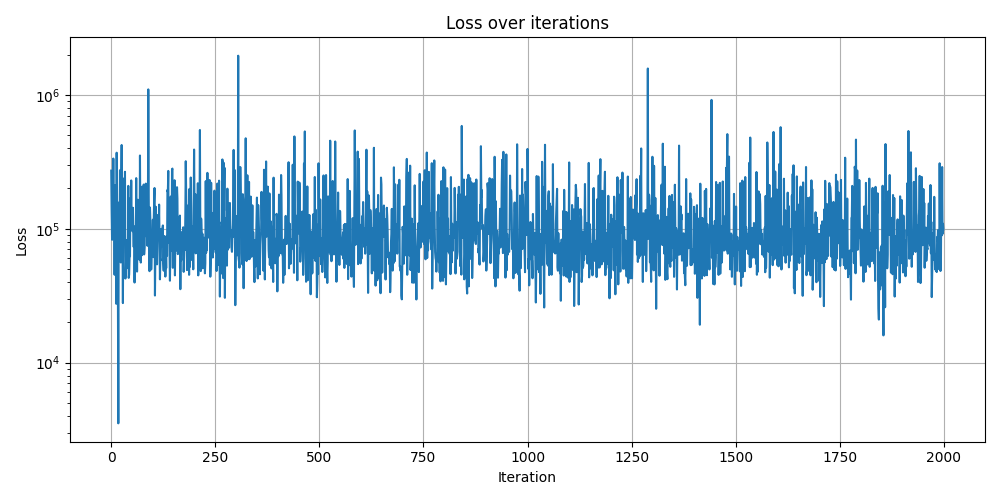

In [42]:
fig, axis = plt.subplots(1, 1, figsize=(10, 5), squeeze = False)

axis[0,0].plot(losses)
axis[0,0].set_title('Loss over iterations')
axis[0,0].set_xlabel('Iteration')
axis[0,0].set_ylabel('Loss')

axis[0,0].grid(True)
axis[0,0].set_yscale('log')
fig.tight_layout()

NameError: name 'gt' is not defined

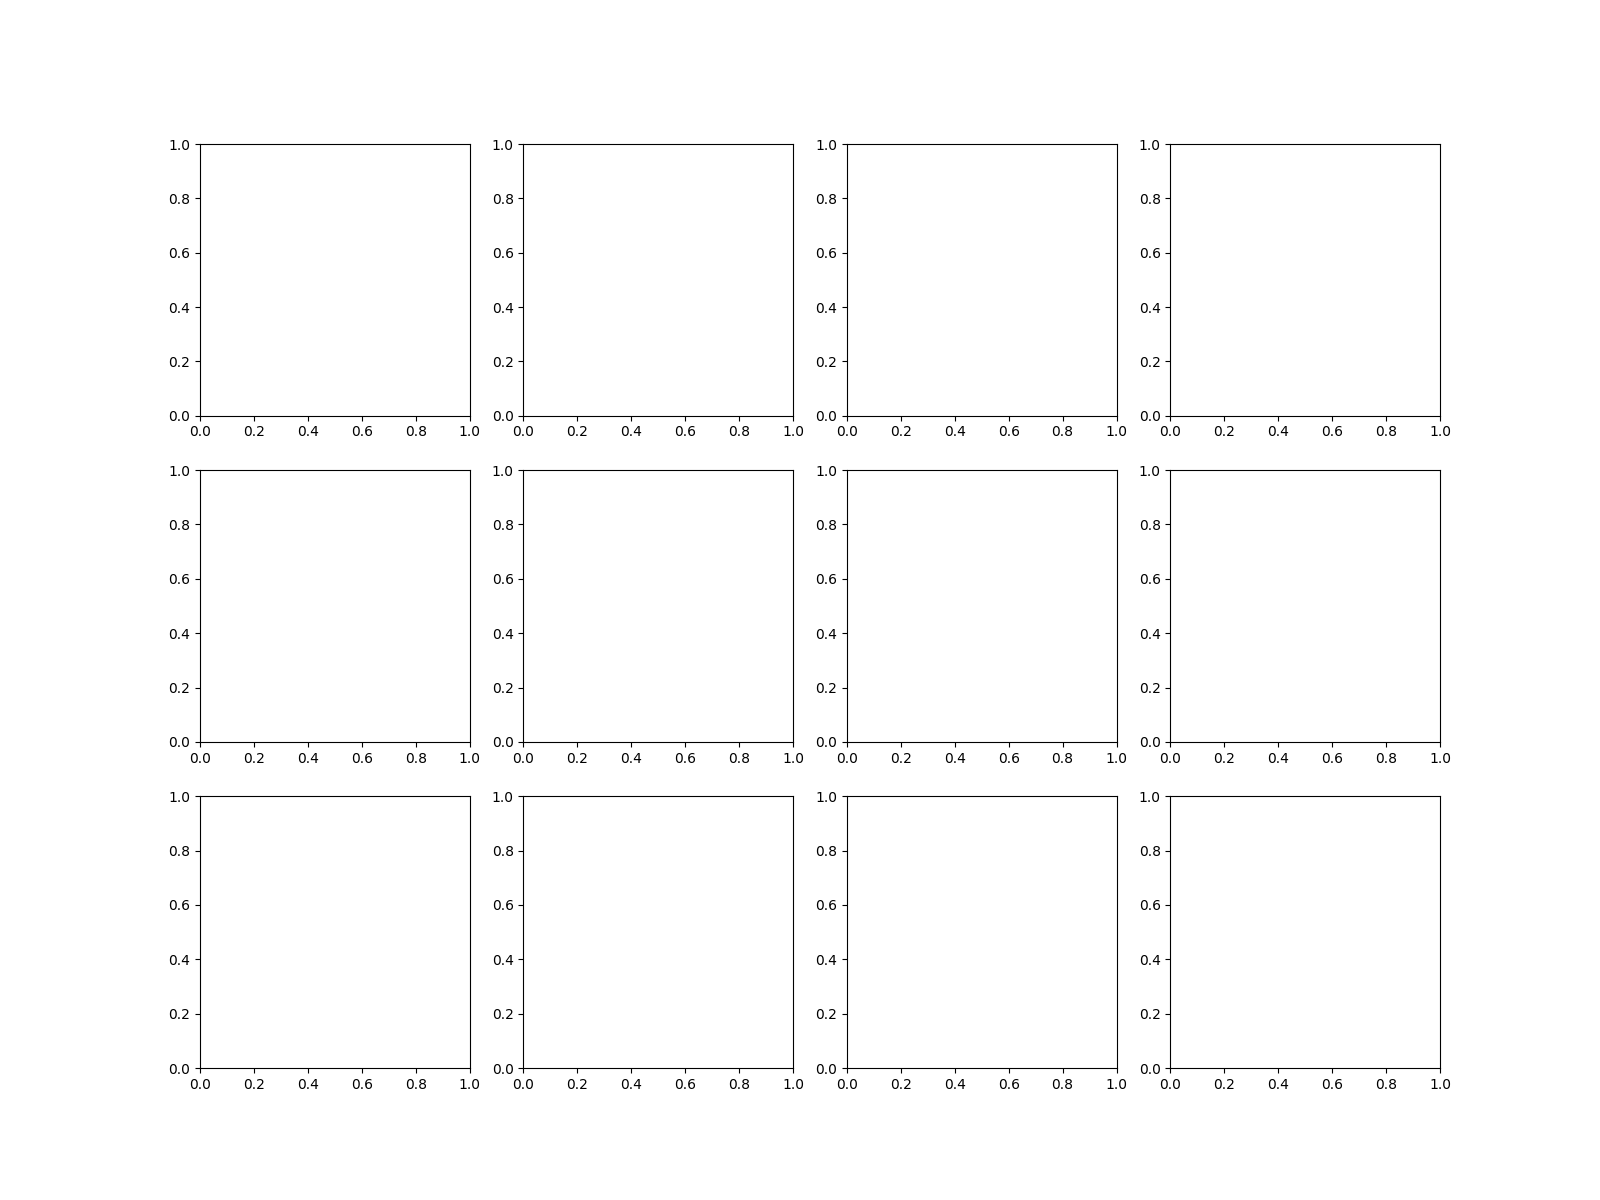

In [43]:
from diffSPH.plotting import visualizeParticles
import matplotlib.pyplot as plt


fig, axis = plt.subplots(3, len(domains), figsize=(len(domains)*4, 12), squeeze = False)

plots = []
axes = axis.flatten()
for b in range(len(domains)):
    plot = visualizeParticles(fig, axis[0,b],
                              particles = currentState,
                              domain = domains[b],
                              quantity = gt[:,0],
                              which = 'both',
                              mapping = 'L2',
                              cmap = 'viridis',
                              visualizeBoth=True,
                              kernel = kernelNameToKernel(configs[b]['kernel']),
                              plotDomain = True,
                              gridVisualization=False, markerSize=2,
                              batch = b)
    axis[0,b].set_title(f'GT Batch {b} {nextData[b]} - t={currentState.time[b]:.2f}s,')
    plots.append(plot)

    plot2 = visualizeParticles(fig, axis[1,b],
                              particles = currentState,
                              domain = domains[b],
                              quantity = out[:,0],
                              which = 'both',
                              mapping = 'L2',
                              cmap = 'viridis',
                              visualizeBoth=True,
                              kernel = kernelNameToKernel(configs[b]['kernel']),
                              plotDomain = True,
                              gridVisualization=False, markerSize=2,
                              batch = b)
    axis[1,b].set_title(f'Pred Batch {b} {nextData[b]} - t={currentState.time[b]:.2f}s,')
    plots.append(plot)

    plot3 = visualizeParticles(fig, axis[2,b],
                              particles = currentState,
                              domain = domains[b],
                              quantity = out[:,0] - gt[:,0],
                              which = 'both',
                              mapping = 'L2',
                              cmap = 'RdBu_r',
                              visualizeBoth=True,
                              kernel = kernelNameToKernel(configs[b]['kernel']),
                              plotDomain = True,
                              gridVisualization=False, markerSize=2,
                              batch = b)
    axis[2,b].set_title(f'Diff Batch {b} {nextData[b]} - t={currentState.time[b]:.2f}s,')
    plots.append(plot3)

fig.tight_layout()

fig.tight_layout()

In [44]:
xx = torch.linspace(-1, 1, 101).to('cuda', dtype = torch.float32)
yy = torch.linspace(-1, 1, 101).to('cuda', dtype = torch.float32)
X, Y = torch.meshgrid(xx, yy, indexing='ij')
edge_attr = torch.stack([X.flatten(), Y.flatten()], dim=-1).to('cuda', dtype = torch.float32)

edge_index = torch.stack([torch.arange(X.numel()).to('cuda'), torch.zeros_like(X).flatten().to(torch.int64)])
inputs = torch.ones_like(X).flatten().unsqueeze(-1).to('cuda', dtype = torch.float32)


print(edge_index.shape, edge_attr.shape, inputs.shape)

out, _ = testLayer(
    x = [inputs, inputs],
    edge_index = edge_index,
    edge_attr = edge_attr,
    batches = 1,
)


torch.Size([2, 10201]) torch.Size([10201, 2]) torch.Size([10201, 1])


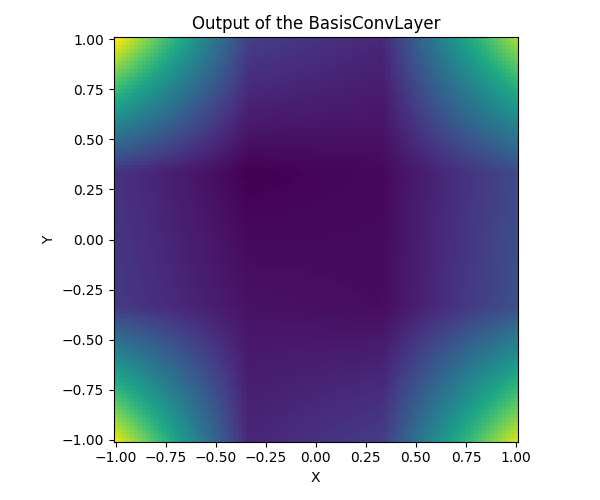

In [45]:
fig, axis = plt.subplots(1, 1, figsize=(6, 5), squeeze = False)

axis[0,0].pcolormesh(X.cpu().numpy(), Y.cpu().numpy(), out[:,0].detach().cpu().numpy().reshape(X.shape), shading='auto', cmap='viridis')

axis[0,0].set_title('Output of the BasisConvLayer')
axis[0,0].set_xlabel('X')
axis[0,0].set_ylabel('Y')
axis[0,0].set_aspect('equal')

fig.tight_layout()